In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from xgboost import XGBClassifier


warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================

cwd = Path.cwd()

if cwd.name.lower() == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd


DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "ai4i2020.csv"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("Current directory:")
print(cwd.resolve())

print("\nProject root:")
print(PROJECT_ROOT.resolve())

print("\nData:")
print(DATA_PATH.resolve())

print("\nModel directory:")
print(MODEL_DIR.resolve())

print("\nProcessed directory:")
print(PROCESSED_DIR.resolve())

Current directory:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\notebooks

Project root:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI

Data:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\data\raw\ai4i2020.csv

Model directory:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\models

Processed directory:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\data\processed


In [3]:
# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(
    DATA_PATH
)


print(
    "Dataset shape:",
    df.shape
)


display(
    df.head()
)

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

print(
    "Machine Failure Counts"
)

display(
    df[
        "Machine failure"
    ]
    .value_counts()
    .rename(
        "Count"
    )
    .to_frame()
)


print(
    "\nMachine Failure Ratio"
)

display(
    df[
        "Machine failure"
    ]
    .value_counts(
        normalize=True
    )
    .rename(
        "Ratio"
    )
    .to_frame()
)

Machine Failure Counts


,Count
Machine failure,
0,9661
1,339



Machine Failure Ratio


,Ratio
Machine failure,
0,0.9661
1,0.0339


In [5]:
# ============================================================
# FEATURES
# ============================================================

FEATURE_COLUMNS = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]


TARGET_COLUMN = (
    "Machine failure"
)


X = (
    df[
        FEATURE_COLUMNS
    ]
    .copy()
)


y = (
    df[
        TARGET_COLUMN
    ]
    .copy()
)


print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)


display(
    X.head()
)

X shape: (10000, 6)
y shape: (10000,)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [6]:
# ============================================================
# OUTER TRAIN / TEST SPLIT
# ============================================================

X_train_full, X_test, y_train_full, y_test = (
    train_test_split(
        X,
        y,

        test_size=0.20,

        random_state=RANDOM_STATE,

        stratify=y
    )
)


print(
    "Training pool:",
    len(
        X_train_full
    )
)

print(
    "Held-out test:",
    len(
        X_test
    )
)


print(
    "\nTraining failure rate:",
    f"{y_train_full.mean():.4f}"
)

print(
    "Test failure rate:",
    f"{y_test.mean():.4f}"
)

Training pool: 8000
Held-out test: 2000

Training failure rate: 0.0339
Test failure rate: 0.0340


In [7]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = (
    train_test_split(
        X_train_full,
        y_train_full,

        test_size=0.20,

        random_state=RANDOM_STATE,

        stratify=y_train_full
    )
)


print(
    "Train:",
    len(
        X_train
    )
)

print(
    "Validation:",
    len(
        X_val
    )
)

print(
    "Test:",
    len(
        X_test
    )
)


print(
    "\nFailure Rates"
)

print(
    f"Train:      {y_train.mean():.4f}"
)

print(
    f"Validation: {y_val.mean():.4f}"
)

print(
    f"Test:       {y_test.mean():.4f}"
)

Train: 6400
Validation: 1600
Test: 2000

Failure Rates
Train:      0.0339
Validation: 0.0338
Test:       0.0340


In [8]:
# ============================================================
# PREPROCESSING
# ============================================================

CATEGORICAL_FEATURES = [
    "Type"
]


NUMERIC_FEATURES = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]


def make_preprocessor():

    return ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                CATEGORICAL_FEATURES
            ),

            (
                "numeric",
                "passthrough",
                NUMERIC_FEATURES
            ),
        ]
    )

In [9]:
# ============================================================
# CLASS IMBALANCE
# ============================================================

negative_count = int(
    (
        y_train
        ==
        0
    ).sum()
)


positive_count = int(
    (
        y_train
        ==
        1
    ).sum()
)


scale_pos_weight = (
    negative_count
    /
    positive_count
)


print(
    "Negative samples:",
    negative_count
)

print(
    "Positive samples:",
    positive_count
)

print(
    "scale_pos_weight:",
    round(
        scale_pos_weight,
        3
    )
)


# ============================================================
# RANDOM FOREST
# ============================================================

rf_model = (
    RandomForestClassifier(
        n_estimators=300,

        max_depth=None,

        class_weight="balanced",

        random_state=RANDOM_STATE,

        n_jobs=-1
    )
)


# ============================================================
# XGBOOST
# ============================================================

xgb_model = (
    XGBClassifier(
        n_estimators=400,

        max_depth=4,

        learning_rate=0.05,

        subsample=0.80,

        colsample_bytree=0.80,

        min_child_weight=1,

        reg_lambda=1.0,

        scale_pos_weight=(
            scale_pos_weight
        ),

        objective=(
            "binary:logistic"
        ),

        eval_metric=(
            "logloss"
        ),

        random_state=(
            RANDOM_STATE
        ),

        n_jobs=-1,

        tree_method="hist"
    )
)

Negative samples: 6183
Positive samples: 217
scale_pos_weight: 28.493


In [10]:
# ============================================================
# PIPELINES
# ============================================================

rf_pipeline = (
    Pipeline(
        steps=[
            (
                "preprocessor",
                make_preprocessor()
            ),

            (
                "model",
                rf_model
            ),
        ]
    )
)


xgb_pipeline = (
    Pipeline(
        steps=[
            (
                "preprocessor",
                make_preprocessor()
            ),

            (
                "model",
                xgb_model
            ),
        ]
    )
)


candidate_models = {

    "Random Forest":
        rf_pipeline,

    "XGBoost":
        xgb_pipeline,
}


candidate_models

{'Random Forest': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('categorical',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['Type']),
                                                  ('numeric', 'passthrough',
                                                   ['Air temperature [K]',
                                                    'Process temperature [K]',
                                                    'Rotational speed [rpm]',
                                                    'Torque [Nm]',
                                                    'Tool wear [min]'])])),
                 ('model',
                  RandomForestClassifier(class_weight='balanced',
                                         n_estimators=300, n_jobs=-1,
                                         random_state=42))]),
 'XGBoost': Pipeline(steps=[('preprocessor',
        

In [11]:
# ============================================================
# TRAIN CANDIDATE MODELS
# ============================================================

for (
    model_name,
    model
) in (
    candidate_models.items()
):

    print(
        f"Training "
        f"{model_name}..."
    )


    model.fit(
        X_train,
        y_train
    )


    print(
        f"{model_name} "
        f"training complete."
    )

    print()

Training Random Forest...
Random Forest training complete.

Training XGBoost...
XGBoost training complete.



In [12]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    probabilities,
    threshold=0.50
):

    predictions = (
        np.asarray(
            probabilities
        )
        >=
        threshold
    ).astype(int)


    return {

        "Threshold":
            float(
                threshold
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "PR-AUC":
            average_precision_score(
                y_true,
                probabilities
            ),
    }

In [13]:
# ============================================================
# VALIDATION PERFORMANCE
# DEFAULT THRESHOLD = 0.50
# ============================================================

validation_probabilities = {}

validation_rows = []


for (
    model_name,
    model
) in (
    candidate_models.items()
):

    probabilities = (
        model.predict_proba(
            X_val
        )[:, 1]
    )


    validation_probabilities[
        model_name
    ] = probabilities


    metrics = (
        calculate_metrics(
            y_val,
            probabilities,
            threshold=0.50
        )
    )


    validation_rows.append(
        {
            "Model":
                model_name,

            **metrics,
        }
    )


validation_default_df = (
    pd.DataFrame(
        validation_rows
    )
    .sort_values(
        "PR-AUC",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    validation_default_df.style.format(
        {
            "Threshold":
                "{:.2f}",

            "Accuracy":
                "{:.4f}",

            "Precision":
                "{:.4f}",

            "Recall":
                "{:.4f}",

            "F1":
                "{:.4f}",

            "ROC-AUC":
                "{:.4f}",

            "PR-AUC":
                "{:.4f}",
        }
    )
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.50,0.9694,0.5325,0.7593,0.6260,0.9748,0.7687
1,Random Forest,0.50,0.9769,0.6667,0.6296,0.6476,0.9630,0.7160


In [14]:
# ============================================================
# THRESHOLD TUNING
# ============================================================

THRESHOLD_GRID = (
    np.round(
        np.arange(
            0.05,
            0.951,
            0.01
        ),
        2
    )
)


def tune_threshold(
    y_true,
    probabilities
):

    rows = []


    for threshold in (
        THRESHOLD_GRID
    ):

        metrics = (
            calculate_metrics(
                y_true,
                probabilities,
                threshold
            )
        )


        rows.append(
            metrics
        )


    results = (
        pd.DataFrame(
            rows
        )
    )


    best_row = (
        results
        .sort_values(
            [
                "F1",
                "Recall",
                "Precision",
            ],

            ascending=[
                False,
                False,
                False,
            ]
        )
        .iloc[0]
    )


    best_threshold = float(
        best_row[
            "Threshold"
        ]
    )


    return (
        best_threshold,
        results
    )

In [15]:
# ============================================================
# TUNE EACH MODEL
# ============================================================

best_thresholds = {}

threshold_sweep_parts = []


for (
    model_name,
    probabilities
) in (
    validation_probabilities.items()
):

    (
        best_threshold,
        threshold_df
    ) = tune_threshold(
        y_val,
        probabilities
    )


    best_thresholds[
        model_name
    ] = (
        best_threshold
    )


    threshold_df[
        "Model"
    ] = (
        model_name
    )


    threshold_sweep_parts.append(
        threshold_df
    )


    print(
        f"{model_name}: "
        f"best threshold = "
        f"{best_threshold:.2f}"
    )


threshold_sweep_df = (
    pd.concat(
        threshold_sweep_parts,
        ignore_index=True
    )
)

Random Forest: best threshold = 0.55
XGBoost: best threshold = 0.81


In [16]:
# ============================================================
# VALIDATION PERFORMANCE
# AFTER THRESHOLD TUNING
# ============================================================

validation_tuned_rows = []


for (
    model_name,
    probabilities
) in (
    validation_probabilities.items()
):

    threshold = (
        best_thresholds[
            model_name
        ]
    )


    metrics = (
        calculate_metrics(
            y_val,
            probabilities,
            threshold
        )
    )


    validation_tuned_rows.append(
        {
            "Model":
                model_name,

            **metrics,
        }
    )


validation_tuned_df = (
    pd.DataFrame(
        validation_tuned_rows
    )
    .sort_values(
        [
            "PR-AUC",
            "F1",
            "Recall",
        ],

        ascending=[
            False,
            False,
            False,
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    validation_tuned_df.style.format(
        {
            "Threshold":
                "{:.2f}",

            "Accuracy":
                "{:.4f}",

            "Precision":
                "{:.4f}",

            "Recall":
                "{:.4f}",

            "F1":
                "{:.4f}",

            "ROC-AUC":
                "{:.4f}",

            "PR-AUC":
                "{:.4f}",
        }
    )
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.81,0.9825,0.7826,0.6667,0.7200,0.9748,0.7687
1,Random Forest,0.55,0.9806,0.7805,0.5926,0.6737,0.9630,0.7160


In [17]:
# ============================================================
# MODEL SELECTION
# ============================================================

selection_table = (
    validation_tuned_df
    .sort_values(
        [
            "PR-AUC",
            "F1",
            "Recall",
        ],

        ascending=[
            False,
            False,
            False,
        ]
    )
    .reset_index(
        drop=True
    )
)


selected_model_name = (
    selection_table.loc[
        0,
        "Model"
    ]
)


selected_threshold = float(
    selection_table.loc[
        0,
        "Threshold"
    ]
)


print(
    "Selected Model:",
    selected_model_name
)


print(
    "Selected Threshold:",
    f"{selected_threshold:.2f}"
)


display(
    selection_table
)

Selected Model: XGBoost
Selected Threshold: 0.81


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.81,0.982500,0.782609,0.666667,0.720000,0.974822,0.768741
1,Random Forest,0.55,0.980625,0.780488,0.592593,0.673684,0.962963,0.716044


In [18]:
# ============================================================
# HELD-OUT TEST EVALUATION
# ============================================================

test_probabilities = {}

test_rows = []


for (
    model_name,
    model
) in (
    candidate_models.items()
):

    probabilities = (
        model.predict_proba(
            X_test
        )[:, 1]
    )


    test_probabilities[
        model_name
    ] = (
        probabilities
    )


    threshold = (
        best_thresholds[
            model_name
        ]
    )


    metrics = (
        calculate_metrics(
            y_test,
            probabilities,
            threshold
        )
    )


    test_rows.append(
        {
            "Model":
                model_name,

            **metrics,
        }
    )


test_results_df = (
    pd.DataFrame(
        test_rows
    )
    .sort_values(
        [
            "PR-AUC",
            "F1",
        ],

        ascending=[
            False,
            False,
        ]
    )
    .reset_index(
        drop=True
    )
)


display(
    test_results_df.style.format(
        {
            "Threshold":
                "{:.2f}",

            "Accuracy":
                "{:.4f}",

            "Precision":
                "{:.4f}",

            "Recall":
                "{:.4f}",

            "F1":
                "{:.4f}",

            "ROC-AUC":
                "{:.4f}",

            "PR-AUC":
                "{:.4f}",
        }
    )
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.81,0.9830,0.7931,0.6765,0.7302,0.9712,0.7953
1,Random Forest,0.55,0.9750,0.6667,0.5294,0.5902,0.9597,0.7134


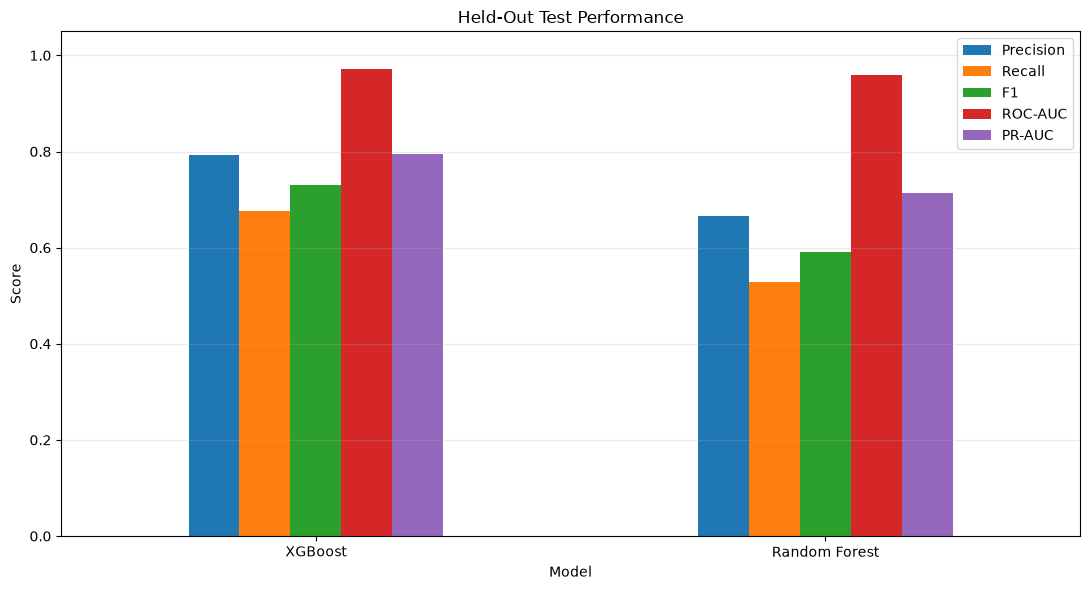

In [19]:
# ============================================================
# MODEL COMPARISON CHART
# ============================================================

plot_df = (
    test_results_df
    .set_index(
        "Model"
    )
    [
        [
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC",
        ]
    ]
)


ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)


ax.set_title(
    "Held-Out Test Performance"
)


ax.set_ylabel(
    "Score"
)


ax.set_ylim(
    0,
    1.05
)


ax.grid(
    axis="y",
    alpha=0.25
)


plt.xticks(
    rotation=0
)


plt.tight_layout()

plt.show()

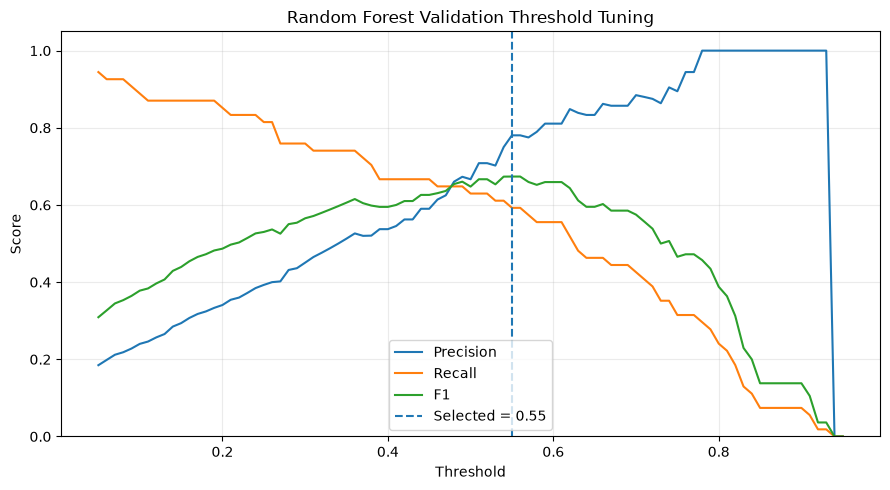

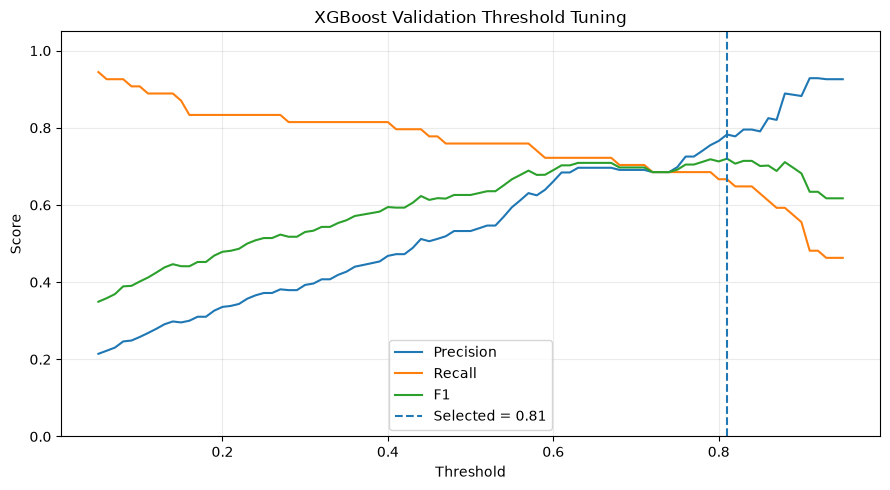

In [20]:
# ============================================================
# THRESHOLD TRADE-OFF
# ============================================================

for model_name in (
    candidate_models.keys()
):

    model_results = (
        threshold_sweep_df[
            threshold_sweep_df[
                "Model"
            ]
            ==
            model_name
        ]
    )


    plt.figure(
        figsize=(9, 5)
    )


    plt.plot(
        model_results[
            "Threshold"
        ],

        model_results[
            "Precision"
        ],

        label="Precision"
    )


    plt.plot(
        model_results[
            "Threshold"
        ],

        model_results[
            "Recall"
        ],

        label="Recall"
    )


    plt.plot(
        model_results[
            "Threshold"
        ],

        model_results[
            "F1"
        ],

        label="F1"
    )


    threshold = (
        best_thresholds[
            model_name
        ]
    )


    plt.axvline(
        threshold,

        linestyle="--",

        label=(
            f"Selected = "
            f"{threshold:.2f}"
        )
    )


    plt.title(
        f"{model_name} "
        f"Validation Threshold Tuning"
    )


    plt.xlabel(
        "Threshold"
    )


    plt.ylabel(
        "Score"
    )


    plt.ylim(
        0,
        1.05
    )


    plt.grid(
        alpha=0.25
    )


    plt.legend()

    plt.tight_layout()

    plt.show()

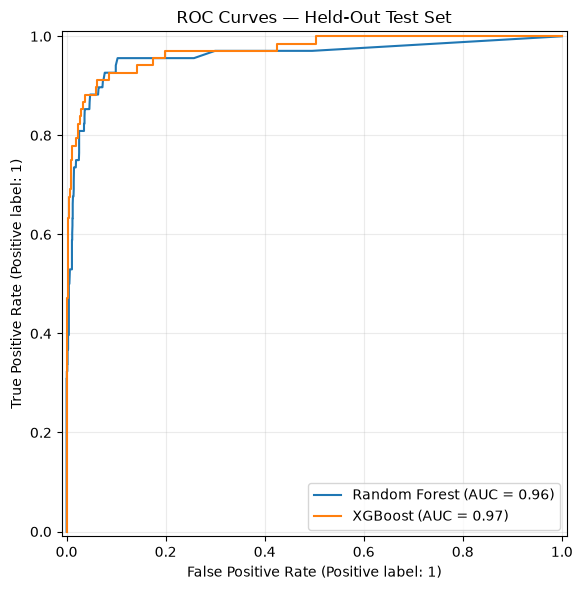

In [21]:
# ============================================================
# ROC CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)


for (
    model_name,
    probabilities
) in (
    test_probabilities.items()
):

    RocCurveDisplay.from_predictions(
        y_test,
        probabilities,
        name=model_name,
        ax=ax
    )


ax.set_title(
    "ROC Curves — Held-Out Test Set"
)


ax.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()

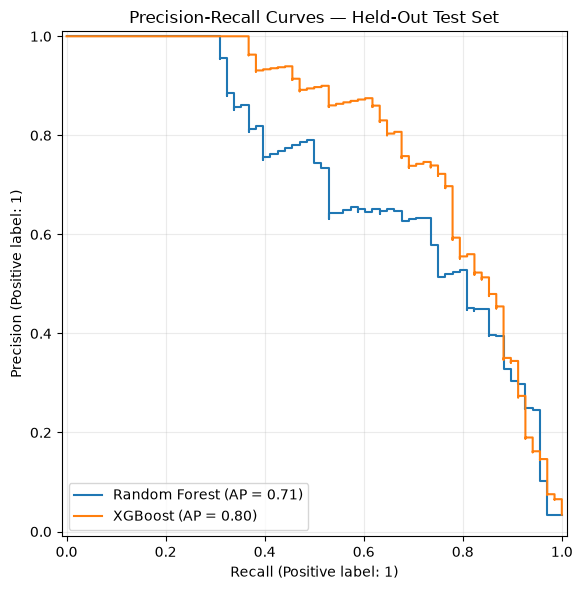

In [22]:
# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)


for (
    model_name,
    probabilities
) in (
    test_probabilities.items()
):

    PrecisionRecallDisplay.from_predictions(
        y_test,
        probabilities,
        name=model_name,
        ax=ax
    )


ax.set_title(
    "Precision-Recall Curves — Held-Out Test Set"
)


ax.grid(
    alpha=0.25
)


plt.tight_layout()

plt.show()

Random Forest
Threshold: 0.55

              precision    recall  f1-score   support

           0     0.9836    0.9907    0.9871      1932
           1     0.6667    0.5294    0.5902        68

    accuracy                         0.9750      2000
   macro avg     0.8251    0.7600    0.7886      2000
weighted avg     0.9728    0.9750    0.9736      2000



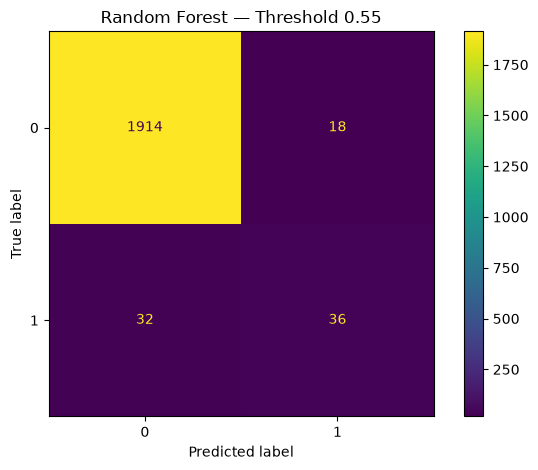

XGBoost
Threshold: 0.81

              precision    recall  f1-score   support

           0     0.9887    0.9938    0.9912      1932
           1     0.7931    0.6765    0.7302        68

    accuracy                         0.9830      2000
   macro avg     0.8909    0.8351    0.8607      2000
weighted avg     0.9820    0.9830    0.9823      2000



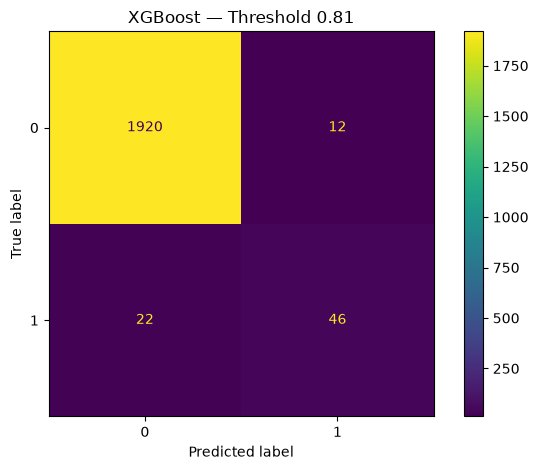

In [23]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

for (
    model_name,
    probabilities
) in (
    test_probabilities.items()
):

    threshold = (
        best_thresholds[
            model_name
        ]
    )


    predictions = (
        probabilities
        >=
        threshold
    ).astype(int)


    print(
        "=" * 70
    )


    print(
        model_name
    )


    print(
        f"Threshold: "
        f"{threshold:.2f}"
    )


    print()


    print(
        classification_report(
            y_test,
            predictions,

            digits=4,

            zero_division=0
        )
    )


    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        values_format="d"
    )


    plt.title(
        f"{model_name} — "
        f"Threshold {threshold:.2f}"
    )


    plt.tight_layout()

    plt.show()

In [24]:
# ============================================================
# SAVE MODEL COMPARISON
# ============================================================

MODEL_COMPARISON_PATH = (
    PROCESSED_DIR
    / "model_comparison.csv"
)


THRESHOLD_SWEEP_PATH = (
    PROCESSED_DIR
    / "threshold_sweep.csv"
)


model_comparison_df = (
    test_results_df.copy()
)


model_comparison_df[
    "Selected"
] = (
    model_comparison_df[
        "Model"
    ]
    ==
    selected_model_name
)


model_comparison_df.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)


threshold_sweep_df.to_csv(
    THRESHOLD_SWEEP_PATH,
    index=False
)


print(
    "Saved:",
    MODEL_COMPARISON_PATH.resolve()
)


print(
    "Saved:",
    THRESHOLD_SWEEP_PATH.resolve()
)


display(
    model_comparison_df
)

Saved: C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\data\processed\model_comparison.csv
Saved: C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\data\processed\threshold_sweep.csv


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Selected
0,XGBoost,0.81,0.983,0.793103,0.676471,0.730159,0.971182,0.795262,True
1,Random Forest,0.55,0.975,0.666667,0.529412,0.590164,0.959692,0.713359,False


In [25]:
# ============================================================
# SAVE CANDIDATE MODELS
# ============================================================

RF_MODEL_PATH = (
    MODEL_DIR
    / "random_forest_candidate.joblib"
)


XGB_MODEL_PATH = (
    MODEL_DIR
    / "xgboost_candidate.joblib"
)


joblib.dump(
    rf_pipeline,
    RF_MODEL_PATH
)


joblib.dump(
    xgb_pipeline,
    XGB_MODEL_PATH
)


print(
    "Saved:",
    RF_MODEL_PATH.resolve()
)


print(
    "Saved:",
    XGB_MODEL_PATH.resolve()
)

Saved: C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\models\random_forest_candidate.joblib
Saved: C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\models\xgboost_candidate.joblib


In [26]:
# ============================================================
# SAVE SELECTED DEPLOYMENT MODEL
# ============================================================

selected_pipeline = (
    candidate_models[
        selected_model_name
    ]
)


BEST_MODEL_PATH = (
    MODEL_DIR
    / "best_model.joblib"
)


joblib.dump(
    selected_pipeline,
    BEST_MODEL_PATH
)


print(
    "Selected deployment model:",
    selected_model_name
)


print(
    "Operating threshold:",
    f"{selected_threshold:.2f}"
)


print(
    "Saved:",
    BEST_MODEL_PATH.resolve()
)

Selected deployment model: XGBoost
Operating threshold: 0.81
Saved: C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\models\best_model.joblib


In [27]:
# ============================================================
# SAVE MODEL METADATA
# ============================================================

selected_test_row = (
    test_results_df[
        test_results_df[
            "Model"
        ]
        ==
        selected_model_name
    ]
    .iloc[0]
)


selected_validation_row = (
    validation_tuned_df[
        validation_tuned_df[
            "Model"
        ]
        ==
        selected_model_name
    ]
    .iloc[0]
)


metadata = {

    "selected_model":
        selected_model_name,

    "selected_threshold":
        float(
            selected_threshold
        ),

    "selection_metric":
        "Validation PR-AUC",

    "threshold_tuning_metric":
        "Validation F1",

    "random_state":
        RANDOM_STATE,

    "feature_columns":
        FEATURE_COLUMNS,

    "validation_metrics": {

        "accuracy":
            float(
                selected_validation_row[
                    "Accuracy"
                ]
            ),

        "precision":
            float(
                selected_validation_row[
                    "Precision"
                ]
            ),

        "recall":
            float(
                selected_validation_row[
                    "Recall"
                ]
            ),

        "f1":
            float(
                selected_validation_row[
                    "F1"
                ]
            ),

        "roc_auc":
            float(
                selected_validation_row[
                    "ROC-AUC"
                ]
            ),

        "pr_auc":
            float(
                selected_validation_row[
                    "PR-AUC"
                ]
            ),
    },

    "test_metrics": {

        "accuracy":
            float(
                selected_test_row[
                    "Accuracy"
                ]
            ),

        "precision":
            float(
                selected_test_row[
                    "Precision"
                ]
            ),

        "recall":
            float(
                selected_test_row[
                    "Recall"
                ]
            ),

        "f1":
            float(
                selected_test_row[
                    "F1"
                ]
            ),

        "roc_auc":
            float(
                selected_test_row[
                    "ROC-AUC"
                ]
            ),

        "pr_auc":
            float(
                selected_test_row[
                    "PR-AUC"
                ]
            ),
    },
}


METADATA_PATH = (
    MODEL_DIR
    / "model_selection_metadata.json"
)


with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metadata,
        file,
        indent=2
    )


print(
    "Saved:",
    METADATA_PATH.resolve()
)


print()


print(
    json.dumps(
        metadata,
        indent=2
    )
)

Saved: C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\models\model_selection_metadata.json

{
  "selected_model": "XGBoost",
  "selected_threshold": 0.81,
  "selection_metric": "Validation PR-AUC",
  "threshold_tuning_metric": "Validation F1",
  "random_state": 42,
  "feature_columns": [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
  ],
  "validation_metrics": {
    "accuracy": 0.9825,
    "precision": 0.782608695652174,
    "recall": 0.6666666666666666,
    "f1": 0.72,
    "roc_auc": 0.9748215226869819,
    "pr_auc": 0.7687409057943699
  },
  "test_metrics": {
    "accuracy": 0.983,
    "precision": 0.7931034482758621,
    "recall": 0.6764705882352942,
    "f1": 0.7301587301587301,
    "roc_auc": 0.9711819510412861,
    "pr_auc": 0.7952619075885468
  }
}


In [28]:
# ============================================================
# REPRESENTATIVE DEMO CANDIDATES
# ============================================================

best_demo_model = joblib.load(
    BEST_MODEL_PATH
)


demo_probabilities = (
    best_demo_model
    .predict_proba(
        X_test
    )[:, 1]
)


demo_candidates = pd.DataFrame(
    {
        "Source Row":
            X_test.index.astype(int),

        "Failure Risk":
            demo_probabilities,

        "Actual Failure":
            y_test.loc[
                X_test.index
            ].to_numpy(),
    }
)


def assign_demo_risk_level(
    probability
):

    if probability >= 0.80:
        return "CRITICAL"

    if probability >= 0.60:
        return "HIGH"

    if probability >= 0.40:
        return "MEDIUM"

    return "LOW"


demo_candidates[
    "Risk Level"
] = (
    demo_candidates[
        "Failure Risk"
    ]
    .apply(
        assign_demo_risk_level
    )
)


demo_candidates[
    "Failure Alert"
] = (
    demo_candidates[
        "Failure Risk"
    ]
    .apply(
        lambda probability:
            (
                "ALERT"
                if probability
                >=
                selected_threshold
                else
                "NORMAL"
            )
    )
)


print(
    "Held-out prediction distribution:"
)


display(
    demo_candidates[
        "Risk Level"
    ]
    .value_counts()
    .reindex(
        [
            "CRITICAL",
            "HIGH",
            "MEDIUM",
            "LOW",
        ],
        fill_value=0
    )
    .rename(
        "Count"
    )
    .to_frame()
)


print(
    "\nPrediction range:"
)


print(
    f"{demo_candidates['Failure Risk'].min():.4f}",
    "to",
    f"{demo_candidates['Failure Risk'].max():.4f}"
)

Held-out prediction distribution:


,Count
Risk Level,
CRITICAL,58
HIGH,20
MEDIUM,29
LOW,1893



Prediction range:
0.0000 to 0.9984


In [29]:
# ============================================================
# RISK-BAND REPRESENTATIVE SAMPLING
# ============================================================

REPRESENTATIVE_RANDOM_SEED = 42


SAMPLES_PER_BAND = {

    "CRITICAL":
        2,

    "HIGH":
        2,

    "MEDIUM":
        2,

    "LOW":
        4,
}


rng = (
    np.random.default_rng(
        REPRESENTATIVE_RANDOM_SEED
    )
)


selected_parts = []


for (
    risk_band,
    requested_count
) in (
    SAMPLES_PER_BAND.items()
):

    band_candidates = (
        demo_candidates[
            demo_candidates[
                "Risk Level"
            ]
            ==
            risk_band
        ]
        .copy()
    )


    available_count = (
        len(
            band_candidates
        )
    )


    sample_count = min(
        requested_count,
        available_count
    )


    print(
        f"{risk_band}: "
        f"{available_count} available, "
        f"{sample_count} selected"
    )


    if sample_count == 0:

        continue


    sampled_indices = (
        rng.choice(

            band_candidates.index.to_numpy(),

            size=sample_count,

            replace=False
        )
    )


    selected_band = (
        band_candidates.loc[
            sampled_indices
        ]
        .copy()
    )


    selected_parts.append(
        selected_band
    )


representative_assets = (
    pd.concat(
        selected_parts,
        ignore_index=True
    )
)


print(
    "\nInitial selected assets:",
    len(
        representative_assets
    )
)

CRITICAL: 58 available, 2 selected
HIGH: 20 available, 2 selected
MEDIUM: 29 available, 2 selected
LOW: 1893 available, 4 selected

Initial selected assets: 10


In [30]:
# ============================================================
# FILL MISSING SLOTS IF NECESSARY
# ============================================================

TARGET_DEMO_ASSET_COUNT = 10


selected_source_rows = set(
    representative_assets[
        "Source Row"
    ]
    .tolist()
)


missing_count = (
    TARGET_DEMO_ASSET_COUNT
    -
    len(
        representative_assets
    )
)


if missing_count > 0:

    print(
        f"Need {missing_count} "
        f"additional observations."
    )


    remaining_candidates = (
        demo_candidates[
            ~demo_candidates[
                "Source Row"
            ]
            .isin(
                selected_source_rows
            )
        ]
        .copy()
    )


    fill_count = min(
        missing_count,
        len(
            remaining_candidates
        )
    )


    fill_indices = (
        rng.choice(

            remaining_candidates
            .index
            .to_numpy(),

            size=fill_count,

            replace=False
        )
    )


    fill_samples = (
        remaining_candidates.loc[
            fill_indices
        ]
        .copy()
    )


    representative_assets = (
        pd.concat(
            [
                representative_assets,
                fill_samples,
            ],

            ignore_index=True
        )
    )


print(
    "Final selected assets:",
    len(
        representative_assets
    )
)

Final selected assets: 10


In [31]:
# ============================================================
# SORT AND ASSIGN DEMO LABELS
# ============================================================

representative_assets = (
    representative_assets
    .sort_values(
        "Failure Risk",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


representative_assets[
    "Asset ID"
] = [

    f"M{index:02d}"

    for index
    in range(
        1,
        len(
            representative_assets
        )
        + 1
    )
]


representative_assets = (
    representative_assets[
        [
            "Asset ID",
            "Source Row",
            "Failure Risk",
            "Risk Level",
            "Failure Alert",
            "Actual Failure",
        ]
    ]
)


display(
    representative_assets.style.format(
        {
            "Failure Risk":
                "{:.1%}"
        }
    )
)

,Asset ID,Source Row,Failure Risk,Risk Level,Failure Alert,Actual Failure
0,M01,4120,90.3%,CRITICAL,ALERT,1
1,M02,4632,86.6%,CRITICAL,ALERT,1
2,M03,8607,79.2%,HIGH,NORMAL,0
3,M04,3592,78.2%,HIGH,NORMAL,0
4,M05,7682,40.4%,MEDIUM,NORMAL,0
5,M06,8025,40.3%,MEDIUM,NORMAL,0
6,M07,8603,8.2%,LOW,NORMAL,0
7,M08,9986,7.8%,LOW,NORMAL,0
8,M09,4525,0.5%,LOW,NORMAL,0
9,M10,3571,0.4%,LOW,NORMAL,0


In [32]:
# ============================================================
# VERIFY BAND DISTRIBUTION
# ============================================================

print(
    "Representative assets by risk band:"
)


display(
    representative_assets[
        "Risk Level"
    ]
    .value_counts()
    .reindex(
        [
            "CRITICAL",
            "HIGH",
            "MEDIUM",
            "LOW",
        ],
        fill_value=0
    )
    .rename(
        "Count"
    )
    .to_frame()
)

Representative assets by risk band:


,Count
Risk Level,
CRITICAL,2
HIGH,2
MEDIUM,2
LOW,4


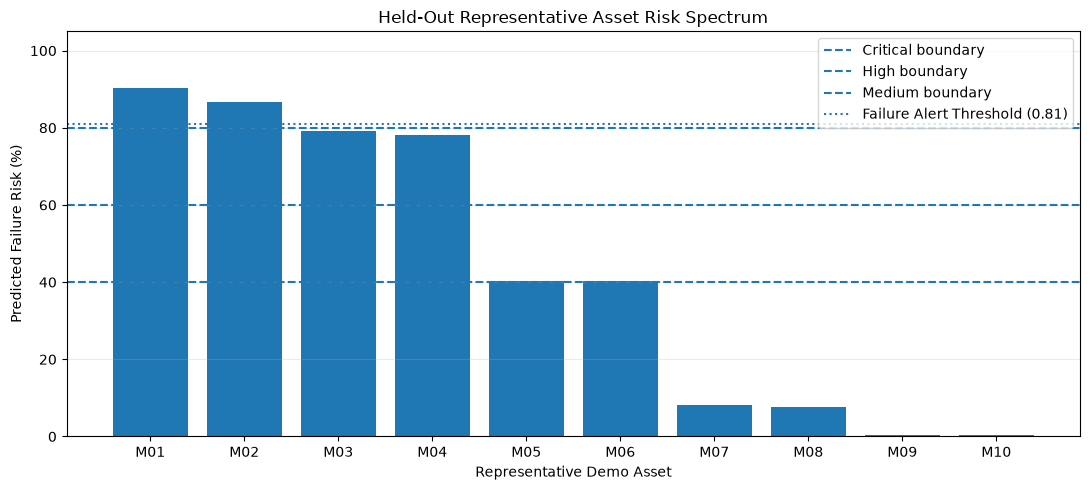

In [33]:
# ============================================================
# REPRESENTATIVE RISK SPECTRUM
# ============================================================

plt.figure(
    figsize=(11, 5)
)


plt.bar(

    representative_assets[
        "Asset ID"
    ],

    representative_assets[
        "Failure Risk"
    ]
    *
    100
)


plt.axhline(
    80,
    linestyle="--",
    label="Critical boundary"
)


plt.axhline(
    60,
    linestyle="--",
    label="High boundary"
)


plt.axhline(
    40,
    linestyle="--",
    label="Medium boundary"
)


plt.axhline(

    selected_threshold
    *
    100,

    linestyle=":",

    label=(
        f"Failure Alert Threshold "
        f"({selected_threshold:.2f})"
    )
)


plt.xlabel(
    "Representative Demo Asset"
)


plt.ylabel(
    "Predicted Failure Risk (%)"
)


plt.title(
    "Held-Out Representative Asset Risk Spectrum"
)


plt.ylim(
    0,
    105
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.legend()


plt.tight_layout()

plt.show()

In [34]:
# ============================================================
# SAVE REPRESENTATIVE ASSET MAPPING
# ============================================================

ASSET_MAPPING_OUTPUT = (
    PROCESSED_DIR
    / "asset_failure_risks.csv"
)


representative_assets.to_csv(
    ASSET_MAPPING_OUTPUT,
    index=False
)


print(
    "Saved:"
)

print(
    ASSET_MAPPING_OUTPUT.resolve()
)


print(
    "\nSaved file verification:"
)


saved_asset_mapping = (
    pd.read_csv(
        ASSET_MAPPING_OUTPUT
    )
)


display(
    saved_asset_mapping.style.format(
        {
            "Failure Risk":
                "{:.1%}"
        }
    )
)

Saved:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\data\processed\asset_failure_risks.csv

Saved file verification:


,Asset ID,Source Row,Failure Risk,Risk Level,Failure Alert,Actual Failure
0,M01,4120,90.3%,CRITICAL,ALERT,1
1,M02,4632,86.6%,CRITICAL,ALERT,1
2,M03,8607,79.2%,HIGH,NORMAL,0
3,M04,3592,78.2%,HIGH,NORMAL,0
4,M05,7682,40.4%,MEDIUM,NORMAL,0
5,M06,8025,40.3%,MEDIUM,NORMAL,0
6,M07,8603,8.2%,LOW,NORMAL,0
7,M08,9986,7.8%,LOW,NORMAL,0
8,M09,4525,0.5%,LOW,NORMAL,0
9,M10,3571,0.4%,LOW,NORMAL,0


In [35]:
# ============================================================
# SAVE REPRESENTATIVE SAMPLING METADATA
# ============================================================

representative_metadata = {

    "sampling_source":
        "Held-out AI4I test set",

    "sampling_method":
        "Fixed-seed random sampling within predefined risk bands",

    "random_seed":
        REPRESENTATIVE_RANDOM_SEED,

    "risk_bands": {

        "CRITICAL":
            "0.80 <= probability <= 1.00",

        "HIGH":
            "0.60 <= probability < 0.80",

        "MEDIUM":
            "0.40 <= probability < 0.60",

        "LOW":
            "0.00 <= probability < 0.40",
    },

    "requested_samples_per_band":
        SAMPLES_PER_BAND,

    "prediction_values_manually_assigned":
        False,
}


REPRESENTATIVE_METADATA_PATH = (
    PROCESSED_DIR
    / "representative_asset_metadata.json"
)


with open(
    REPRESENTATIVE_METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        representative_metadata,
        file,
        indent=2
    )


print(
    "Saved:"
)

print(
    REPRESENTATIVE_METADATA_PATH.resolve()
)

Saved:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\data\processed\representative_asset_metadata.json


In [36]:
# ============================================================
# FINAL SUMMARY
# ============================================================

selected_test_row = (
    test_results_df[
        test_results_df[
            "Model"
        ]
        ==
        selected_model_name
    ]
    .iloc[0]
)


print(
    "=" * 70
)

print(
    "MAINTENROUTE AI"
)

print(
    "MODEL SELECTION SUMMARY"
)

print(
    "=" * 70
)


print(
    "\nSelected Model:"
)

print(
    selected_model_name
)


print(
    "\nSelected Threshold:"
)

print(
    f"{selected_threshold:.2f}"
)


print(
    "\nHeld-Out Test Metrics:"
)


for metric in [

    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC",

]:

    value = float(
        selected_test_row[
            metric
        ]
    )


    print(
        f"{metric:10s}: "
        f"{value:.4f}"
    )


print(
    "\nRepresentative Demo Asset Policy:"
)

print(
    "Held-out observations sampled randomly "
    "within predefined risk bands."
)

print(
    f"Sampling seed: "
    f"{REPRESENTATIVE_RANDOM_SEED}"
)


print(
    "\nNo displayed failure probability "
    "is manually assigned."
)


print(
    "\nArtifacts:"
)

print(
    BEST_MODEL_PATH.resolve()
)

print(
    METADATA_PATH.resolve()
)

print(
    MODEL_COMPARISON_PATH.resolve()
)

print(
    ASSET_MAPPING_OUTPUT.resolve()
)

print(
    REPRESENTATIVE_METADATA_PATH.resolve()
)

MAINTENROUTE AI
MODEL SELECTION SUMMARY

Selected Model:
XGBoost

Selected Threshold:
0.81

Held-Out Test Metrics:
Accuracy  : 0.9830
Precision : 0.7931
Recall    : 0.6765
F1        : 0.7302
ROC-AUC   : 0.9712
PR-AUC    : 0.7953

Representative Demo Asset Policy:
Held-out observations sampled randomly within predefined risk bands.
Sampling seed: 42

No displayed failure probability is manually assigned.

Artifacts:
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\models\best_model.joblib
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\models\model_selection_metadata.json
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\data\processed\model_comparison.csv
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\data\processed\asset_failure_risks.csv
C:\Users\kwyo1\OneDrive\Desktop\ABB\MaintenRouteAI\data\processed\representative_asset_metadata.json
